# 4 - Supplementary figures S1 and S3: running-window RM-ANOVA

Repeated-measures ANOVAs fitted at every step of a 100 ms sliding window
(-500 to +1000 ms, 25 ms step, 61 windows).
**2 x 3 within-subjects design**: congruency (congruent / incongruent) x
saccade amplitude (low / medium / high tertile). Amplitude tertiles are set
per subject from pre-sound saccades only.

Results are drawn as heatmaps: rows = effects, x-axis = time, colour = F.
Uncorrected (p < .05) in grey, FDR-corrected (Benjamini-Hochberg) in black.

## Outcomes
- **saccade_count_normalized** - Figure S1
- **p_correct_response** - Figure S3

The ANOVAs are fitted in base R. This notebook writes `stats_anova_running.R`
and runs it with `Rscript`; edit the generating cell, never the `.R` file.

**Input**   `data_preprocessed/{EX_1,EX_9,EX_7,EX_3}/long_format_alt_all.csv`
**Outputs** `data_for_stats_anova_rw/{EXP}_conditions.csv` (input for R),
            `summaries/stats/anova_running/anova_results_running.csv`,
            `summaries/plots/` figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import sys, importlib, subprocess, shutil

sys.path.insert(0, 'src')
import config as cfg
importlib.reload(cfg)
from config import load_experiment_data, build_filter
from peri_sac import calculate_running_window_metrics
from binning import assign_quantile_bins_presound

plt.rcParams['pdf.fonttype'] = 42  # embed TrueType fonts in PDF (not outlines)
plt.rcParams['ps.fonttype'] = 42

print('Modules loaded.')

Modules loaded.


## Configuration

In [10]:
# ── Experiments ──────────────────────────────────────────────────
EXPERIMENTS = ['EX_1', 'EX_9', 'EX_7', 'EX_3']
EXPERIMENT_LABELS = {
    'EX_1': 'Exp 1a. binaural-direction',
    'EX_9': 'Exp 1b. binaural-direction',
    'EX_7': 'Exp 2. monaural-direction',
    'EX_3': 'Exp 3. monaural-pitch',
}

# ── Time axis ────────────────────────────────────────────────────
TIME_REFERENCE = 'time_from_sound_to_sacc_start'
TIME_RANGE     = (-500, 1000)   # ms
WINDOW_SIZE    = 100            # ms
STEP_SIZE      = 25             # ms
BASELINE_RANGE = (-500, 0)      # ms — per-condition normalization baseline

# ── Amplitude binning ─────────────────────────────────────────────
N_AMPLITUDE_BINS             = 3    # tertile split
AMPLITUDE_PRESOUND_THRESHOLD = 0    # ms: use only pre-sound saccades for binning

# ── Paths ─────────────────────────────────────────────────────────
DATA_PATH  = Path('data_for_stats_anova_rw')
STATS_PATH = Path('summaries/stats/anova_running')
R_SCRIPT   = 'stats_anova_running.R'

DATA_PATH.mkdir(parents=True, exist_ok=True)
STATS_PATH.mkdir(parents=True, exist_ok=True)

print(f'Experiments  : {EXPERIMENTS}')
print(f'Time range   : {TIME_RANGE} ms')
print(f'Window size  : {WINDOW_SIZE} ms')
print(f'Step size    : {STEP_SIZE} ms')
print(f'Baseline     : {BASELINE_RANGE} ms')
n_windows = len(np.arange(TIME_RANGE[0], TIME_RANGE[1] + STEP_SIZE, STEP_SIZE))
print(f'N windows    : {n_windows}')
print(f'DATA_PATH    : {DATA_PATH}')
print(f'STATS_PATH   : {STATS_PATH}')


Experiments  : ['EX_1', 'EX_9', 'EX_7', 'EX_3']
Time range   : (-500, 1000) ms
Window size  : 100 ms
Step size    : 25 ms
Baseline     : (-500, 0) ms
N windows    : 61
DATA_PATH    : data_for_stats_anova_rw
STATS_PATH   : summaries\stats\anova_running


## Load Data

In [3]:
raw_data = {}

for exp in EXPERIMENTS:
    exp_dir = Path(f'data_preprocessed/{exp}')
    if not exp_dir.exists():
        print(f'WARNING: {exp} — directory not found: {exp_dir}')
        continue
    data = load_experiment_data(exp)
    raw_data[exp] = data
    filt = build_filter(data)
    n_subj = data['id_subject'].nunique()
    print(f'{exp}: {len(data):,} rows total, {filt.sum():,} pass filter, {n_subj} subjects')

print(f'\nLoaded: {list(raw_data.keys())}')


Loading alt data: long_format_alt_all.csv


  Raw data loaded: 248,227 rows
  Unique subjects: 52
  Data prepared using closest sound approach
EX_1: 248,227 rows total, 228,697 pass filter, 52 subjects
Loading alt data: long_format_alt_all.csv


  Raw data loaded: 192,094 rows
  Unique subjects: 40
  Data prepared using closest sound approach
EX_9: 192,094 rows total, 176,942 pass filter, 40 subjects
Loading alt data: long_format_alt_all.csv


  Raw data loaded: 188,481 rows
  Unique subjects: 40
  Data prepared using closest sound approach
EX_7: 188,481 rows total, 167,965 pass filter, 40 subjects
Loading alt data: long_format_alt_all.csv
  Raw data loaded: 218,688 rows
  Unique subjects: 46
  Data prepared using closest sound approach
EX_3: 218,688 rows total, 192,936 pass filter, 46 subjects

Loaded: ['EX_1', 'EX_9', 'EX_7', 'EX_3']


## Prepare Variables

In [4]:
def prepare_exp(data, exp):
    filt = build_filter(data)
    df   = data[filt].copy()

    # Amplitude bins: tertile split on pre-sound saccades, per-subject
    df = assign_quantile_bins_presound(
        df,
        n_bins=N_AMPLITUDE_BINS,
        value_col='amplitude_deg',
        per_subject=True,
        presound_threshold=AMPLITUDE_PRESOUND_THRESHOLD,
    )
    df = df.rename(columns={'quantile_bin': 'amplitude_bin'})

    # Consistency category (uses 'consistent' boolean from load_experiment_data)
    df['consistency_cat'] = df['consistent'].map({True: 'consistent', False: 'inconsistent'})

    return df


prepared = {}
for exp, data in raw_data.items():
    df = prepare_exp(data, exp)
    prepared[exp] = df
    n_nan = df['amplitude_bin'].isna().sum()
    print(f'{exp}: {len(df):,} trials, {df["id_subject"].nunique()} subjects')
    print(f'  amplitude_bin NaN: {n_nan:,} ({100*n_nan/len(df):.1f}%)')
    print(f'  bins: {sorted(df["amplitude_bin"].dropna().unique())}')
    print(f'  consistency: {df["consistency_cat"].value_counts().to_dict()}')


Calculating quantiles based on 118195 pre-sound observations
  (out of 228697 total valid observations)


EX_1: 228,697 trials, 52 subjects
  amplitude_bin NaN: 0 (0.0%)
  bins: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  consistency: {'inconsistent': 114377, 'consistent': 114320}
Calculating quantiles based on 90766 pre-sound observations
  (out of 176942 total valid observations)


EX_9: 176,942 trials, 40 subjects
  amplitude_bin NaN: 0 (0.0%)
  bins: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  consistency: {'inconsistent': 88484, 'consistent': 88458}
Calculating quantiles based on 84769 pre-sound observations
  (out of 167965 total valid observations)


EX_7: 167,965 trials, 39 subjects
  amplitude_bin NaN: 0 (0.0%)
  bins: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  consistency: {'inconsistent': 84160, 'consistent': 83805}
Calculating quantiles based on 98253 pre-sound observations
  (out of 192936 total valid observations)
EX_3: 192,936 trials, 46 subjects
  amplitude_bin NaN: 0 (0.0%)
  bins: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  consistency: {'consistent': 96798, 'inconsistent': 96138}


## Compute Per-Condition Running Window Metrics

For each of the **6 conditions** (2 consistency × 3 amplitude bins), run `calculate_running_window_metrics`.
Each call returns per-subject, per-window aggregates including `p_correct_response` and
`saccade_count_normalized` (% change relative to per-condition baseline in `BASELINE_RANGE`).

This matches §3 and §5 of `explore_peri_saccades_alt2.ipynb`.


In [5]:
CONSISTENCY_CATS = ['consistent', 'inconsistent']
AMPLITUDE_BINS   = list(range(1, N_AMPLITUDE_BINS + 1))

all_exp_results = {}

for exp, df in prepared.items():
    print(f'\n--- {exp} ---')
    parts = []

    for cons_cat in CONSISTENCY_CATS:
        for amp_bin in AMPLITUDE_BINS:
            cond_filter = (
                (df['consistency_cat'] == cons_cat) &
                (df['amplitude_bin']   == amp_bin)
            )
            n = cond_filter.sum()
            print(f'  {cons_cat} + bin {amp_bin}: {n:,} trials', end='')

            if n < 30:
                print(' — SKIP (too few trials)')
                continue

            res = calculate_running_window_metrics(
                df, cond_filter, TIME_REFERENCE,
                window_size=WINDOW_SIZE, step_size=STEP_SIZE,
                time_range=TIME_RANGE, baseline_range=BASELINE_RANGE,
            )
            res['consistency_cat'] = cons_cat
            res['amplitude_bin']   = amp_bin
            parts.append(res)
            print(f' → {len(res):,} subject-window rows')

    if parts:
        combined = pd.concat(parts, ignore_index=True)
        all_exp_results[exp] = combined
        print(f'  Combined: {len(combined):,} rows')

print('\nDone.')



--- EX_1 ---
  consistent + bin 1: 37,407 trials → 3,111 subject-window rows
  consistent + bin 2: 37,806 trials → 3,106 subject-window rows
  consistent + bin 3: 39,107 trials → 3,105 subject-window rows
  inconsistent + bin 1: 37,474 trials → 3,106 subject-window rows
  inconsistent + bin 2: 37,400 trials → 3,111 subject-window rows
  inconsistent + bin 3: 39,503 trials → 3,111 subject-window rows
  Combined: 18,650 rows

--- EX_9 ---
  consistent + bin 1: 28,834 trials → 2,432 subject-window rows
  consistent + bin 2: 29,651 trials → 2,437 subject-window rows
  consistent + bin 3: 29,973 trials → 2,439 subject-window rows
  inconsistent + bin 1: 29,017 trials → 2,434 subject-window rows
  inconsistent + bin 2: 29,250 trials → 2,432 subject-window rows
  inconsistent + bin 3: 30,217 trials → 2,432 subject-window rows
  Combined: 14,606 rows

--- EX_7 ---
  consistent + bin 1: 27,763 trials → 2,378 subject-window rows
  consistent + bin 2: 27,465 trials → 2,379 subject-window rows
  

## Save Condition Metrics for R

In [6]:
SAVE_COLS = [
    'id_subject', 'window_center', 'consistency_cat', 'amplitude_bin',
    'p_correct_response', 'saccade_count_normalized', 'sound_count',
]

for exp, df_res in all_exp_results.items():
    out  = DATA_PATH / f'{exp}_conditions.csv'
    save = df_res[SAVE_COLS].rename(columns={'id_subject': 'subject'})
    save.to_csv(out, index=False)
    print(f'Saved: {out}  ({len(save):,} rows)')
    per_cond = save.groupby(['consistency_cat', 'amplitude_bin']).size()
    print(f'  Rows per condition (subject-window count):\n{per_cond.to_string()}')


Saved: data_for_stats_anova_rw\EX_1_conditions.csv  (18,650 rows)
  Rows per condition (subject-window count):
consistency_cat  amplitude_bin
consistent       1                3111
                 2                3106
                 3                3105
inconsistent     1                3106
                 2                3111
                 3                3111
Saved: data_for_stats_anova_rw\EX_9_conditions.csv  (14,606 rows)
  Rows per condition (subject-window count):
consistency_cat  amplitude_bin
consistent       1                2432
                 2                2437
                 3                2439
inconsistent     1                2434
                 2                2432
                 3                2432
Saved: data_for_stats_anova_rw\EX_7_conditions.csv  (14,271 rows)
  Rows per condition (subject-window count):
consistency_cat  amplitude_bin
consistent       1                2378
                 2                2379
                 3          

## Generate R Script

In [7]:
data_path_r  = str(DATA_PATH).replace('\\', '/')
stats_path_r = str(STATS_PATH).replace('\\', '/')

exps_r    = ', '.join('"' + e + '"' for e in EXPERIMENTS)
win_cents = list(np.arange(TIME_RANGE[0], TIME_RANGE[1] + STEP_SIZE, STEP_SIZE).astype(int))
win_r     = ', '.join(str(w) for w in win_cents)

# Dynamic amplitude bin levels / labels for R
_all_labels = ['low', 'medium', 'high', 'q4', 'q5', 'q6']
amp_levels_r = ', '.join(str(i) for i in range(1, N_AMPLITUDE_BINS + 1))
amp_labels_r = ', '.join(f'"{_all_labels[i]}"' for i in range(N_AMPLITUDE_BINS))
n_cells      = 2 * N_AMPLITUDE_BINS   # 2 consistency levels × N amplitude bins

r_lines = []
r_lines.append('# =============================================================')
r_lines.append('# Running-window RM-ANOVA: Consistency x Amplitude')
r_lines.append('# Generated by 04_stats_anova.ipynb - do not edit by hand')
r_lines.append('# =============================================================')
r_lines.append('')
r_lines.append(f'DATA_PATH    <- "{data_path_r}"')
r_lines.append(f'STATS_PATH   <- "{stats_path_r}"')
r_lines.append(f'EXPERIMENTS  <- c({exps_r})')
r_lines.append(f'WIN_CENTERS  <- c({win_r})')
r_lines.append('OUTCOMES     <- c("p_correct_response", "saccade_count_normalized")')
r_lines.append('MIN_SOUND    <- 5L    # min sound count per subject-cell')
r_lines.append('MIN_SUBJECTS <- 10L   # min complete-data subjects per window')
r_lines.append('')
r_lines.append('dir.create(STATS_PATH, recursive = TRUE, showWarnings = FALSE)')
r_lines.append('')
r_lines.append('# ── extract F/p for one named effect from aov() summary ───')
r_lines.append('extract_effect <- function(s, effect_name) {')
r_lines.append('  for (sname in names(s)) {')
r_lines.append('    tab <- s[[sname]][[1]]')
r_lines.append('    if (!is.null(tab) && effect_name %in% rownames(tab)) {')
r_lines.append('      df_num <- as.integer(tab[effect_name, "Df"])')
r_lines.append('      df_den <- if ("Residuals" %in% rownames(tab))')
r_lines.append('                  as.integer(tab["Residuals", "Df"]) else NA_integer_')
r_lines.append('      return(data.frame(')
r_lines.append('        effect  = effect_name,')
r_lines.append('        F_value = as.numeric(tab[effect_name, "F value"]),')
r_lines.append('        p_value = as.numeric(tab[effect_name, "Pr(>F)"]),')
r_lines.append('        df_num  = df_num,')
r_lines.append('        df_den  = df_den,')
r_lines.append('        stringsAsFactors = FALSE')
r_lines.append('      ))')
r_lines.append('    }')
r_lines.append('  }')
r_lines.append('  data.frame(effect=effect_name, F_value=NA_real_, p_value=NA_real_,')
r_lines.append('             df_num=NA_integer_, df_den=NA_integer_, stringsAsFactors=FALSE)')
r_lines.append('}')
r_lines.append('')
r_lines.append('all_results <- list()')
r_lines.append('total_wins  <- length(EXPERIMENTS) * length(WIN_CENTERS)')
r_lines.append('done        <- 0L')
r_lines.append('')
r_lines.append('for (exp in EXPERIMENTS) {')
r_lines.append('  fpath <- file.path(DATA_PATH, paste0(exp, "_conditions.csv"))')
r_lines.append('  if (!file.exists(fpath)) { cat("SKIP", exp, "\\n"); next }')
r_lines.append('  d <- read.csv(fpath, stringsAsFactors = FALSE)')
r_lines.append('  d$consistency_cat <- factor(d$consistency_cat,')
r_lines.append('                              levels = c("consistent", "inconsistent"))')
r_lines.append(f'  d$amplitude_bin   <- factor(d$amplitude_bin, levels = c({amp_levels_r}),')
r_lines.append(f'                              labels = c({amp_labels_r}))')
r_lines.append('  d$subject         <- factor(d$subject)')
r_lines.append('  cat(sprintf("\\n=== %s  (%d rows) ===\\n", exp, nrow(d)))')
r_lines.append('')
r_lines.append('  for (win_c in WIN_CENTERS) {')
r_lines.append('    done <- done + 1L')
r_lines.append('    if (done %% 20 == 0) cat(sprintf("  progress: %d / %d\\n", done, total_wins))')
r_lines.append('')
r_lines.append('    win_data <- d[d$window_center == win_c, ]')
r_lines.append('    win_data <- win_data[win_data$sound_count >= MIN_SOUND, ]')
r_lines.append('    if (nrow(win_data) == 0) next')
r_lines.append('')
r_lines.append('    cell_key     <- paste(win_data$consistency_cat, win_data$amplitude_bin)')
r_lines.append('    n_cells_subj <- tapply(cell_key, win_data$subject,')
r_lines.append('                           function(x) length(unique(x)))')
r_lines.append(f'    complete_subs <- names(n_cells_subj)[n_cells_subj == {n_cells}L]')
r_lines.append('')
r_lines.append('    for (outcome in OUTCOMES) {')
r_lines.append('      win_out <- win_data[win_data$subject %in% complete_subs &')
r_lines.append('                          !is.na(win_data[[outcome]]), ]')
r_lines.append('      n_cells2 <- tapply(')
r_lines.append('        paste(win_out$consistency_cat, win_out$amplitude_bin),')
r_lines.append('        win_out$subject, function(x) length(unique(x)))')
r_lines.append(f'      complete_subs2 <- names(n_cells2)[n_cells2 == {n_cells}L]')
r_lines.append('      if (length(complete_subs2) < MIN_SUBJECTS) next')
r_lines.append('      win_final         <- win_out[win_out$subject %in% complete_subs2, ]')
r_lines.append('      win_final$subject <- droplevels(win_final$subject)')
r_lines.append('')
r_lines.append('      tryCatch({')
r_lines.append('        fml_str <- paste0(outcome,')
r_lines.append('          " ~ consistency_cat * amplitude_bin + Error(subject/(consistency_cat * amplitude_bin))")')
r_lines.append('        fit <- aov(as.formula(fml_str), data = win_final)')
r_lines.append('        s   <- summary(fit)')
r_lines.append('')
r_lines.append('        for (eff in c("consistency_cat", "amplitude_bin",')
r_lines.append('                      "consistency_cat:amplitude_bin")) {')
r_lines.append('          row <- extract_effect(s, eff)')
r_lines.append('          row$experiment    <- exp')
r_lines.append('          row$window_center <- win_c')
r_lines.append('          row$outcome       <- outcome')
r_lines.append('          row$n_subjects    <- length(complete_subs2)')
r_lines.append('          all_results[[length(all_results)+1]] <- row')
r_lines.append('        }')
r_lines.append('      }, error = function(e) NULL)')
r_lines.append('    }')
r_lines.append('  }')
r_lines.append('}')
r_lines.append('')
r_lines.append('if (length(all_results) > 0) {')
r_lines.append('  results_df <- do.call(rbind, all_results)')
r_lines.append('  out_file   <- file.path(STATS_PATH, "anova_results_running.csv")')
r_lines.append('  write.csv(results_df, out_file, row.names = FALSE)')
r_lines.append('  cat(sprintf("\\n✓ Saved: %s  (%d rows)\\n", out_file, nrow(results_df)))')
r_lines.append('} else {')
r_lines.append('  cat("WARNING: No results collected!\\n")')
r_lines.append('}')

r_script = '\n'.join(r_lines)
with open(R_SCRIPT, 'w', encoding='utf-8') as f:
    f.write(r_script)

print(f'R script written: {R_SCRIPT}')
print(f'Windows: {len(win_cents)} centers from {win_cents[0]} to {win_cents[-1]} ms')
print(f'Amplitude bins: {N_AMPLITUDE_BINS}  (levels: {amp_levels_r}, labels: {amp_labels_r})')
print(f'Required cells per subject: {n_cells}')


R script written: stats_anova_running.R
Windows: 61 centers from -500 to 1000 ms
Amplitude bins: 3  (levels: 1, 2, 3, labels: "low", "medium", "high")
Required cells per subject: 6


## Run R Script

Fits repeated measures ANOVA per window (~63 windows × 3 experiments × 2 outcomes).
Base R only — no extra packages required. Expect **1–3 minutes**.

In [8]:
rscript = shutil.which('Rscript') or shutil.which('Rscript.exe')
if rscript is None:
    candidates = sorted(Path('C:/Program Files/R').glob('*/bin/Rscript.exe'), reverse=True)
    if candidates:
        rscript = str(candidates[0])

if rscript is None:
    raise FileNotFoundError('Rscript not found.')

print(f'Using: {rscript}')
print(f'Running: {R_SCRIPT} ...')

result = subprocess.run([rscript, R_SCRIPT], capture_output=True, text=True)
print(result.stdout[-4000:])
if result.returncode != 0:
    print('--- STDERR ---')
    print(result.stderr[-2000:])


Using: C:\Program Files\R\R-4.5.2\bin\Rscript.exe
Running: stats_anova_running.R ...

=== EX_1  (18650 rows) ===
  progress: 20 / 244
  progress: 40 / 244
  progress: 60 / 244

=== EX_9  (14606 rows) ===
  progress: 80 / 244
  progress: 100 / 244
  progress: 120 / 244

=== EX_7  (14271 rows) ===
  progress: 140 / 244
  progress: 160 / 244
  progress: 180 / 244

=== EX_3  (16836 rows) ===
  progress: 200 / 244
  progress: 220 / 244
  progress: 240 / 244

âœ“ Saved: summaries/stats/anova_running/anova_results_running.csv  (1464 rows)



## Load Results & Plot Heatmap

Loaded 1,464 rows
Experiments  : ['EX_1', 'EX_3', 'EX_7', 'EX_9']
Window range : [-500, 1000] ms
N windows    : 61
Outcomes     : ['p_correct_response', 'saccade_count_normalized']
Effects      : ['amplitude_bin', 'consistency_cat', 'consistency_cat:amplitude_bin']

Significant p<.05: 376  |  FDR-corrected: 225
Significance bar: grey = p<.05, black = FDR-corrected


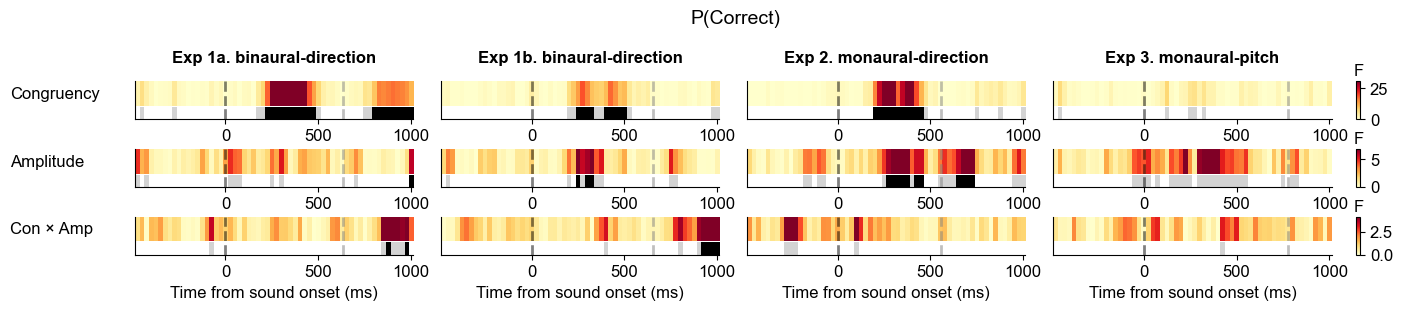

Saved: summaries\stats\anova_running\anova_running_heatmap_p_correct_response.png
Saved: summaries\stats\anova_running\anova_running_heatmap_p_correct_response.pdf


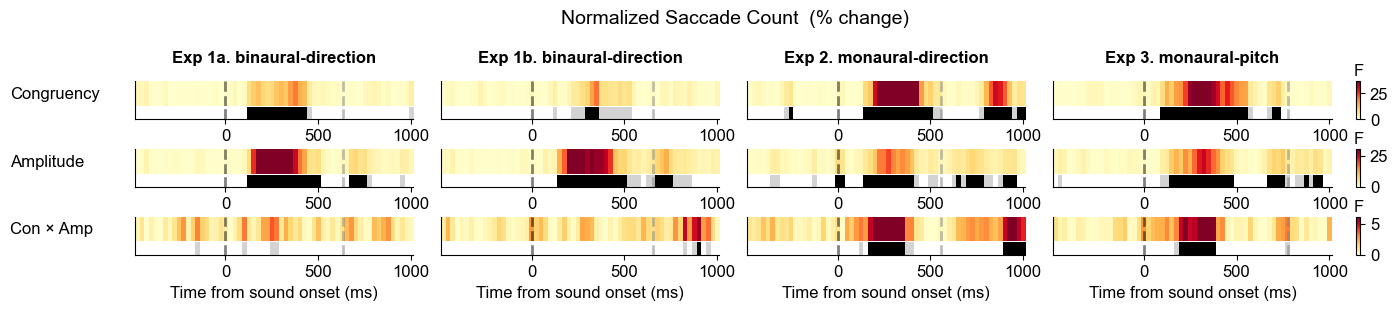

Saved: summaries\stats\anova_running\anova_running_heatmap_saccade_count_normalized.png
Saved: summaries\stats\anova_running\anova_running_heatmap_saccade_count_normalized.pdf


In [13]:
from matplotlib.colors import ListedColormap
from statsmodels.stats.multitest import multipletests

results_file = STATS_PATH / 'anova_results_running.csv'
if not results_file.exists():
    raise FileNotFoundError(f'Results not found: {results_file}\nRun the R script first.')

res = pd.read_csv(results_file)

print(f'Loaded {len(res):,} rows')
print(f'Experiments  : {sorted(res["experiment"].unique())}')
print(f'Window range : [{res["window_center"].min()}, {res["window_center"].max()}] ms')
print(f'N windows    : {res["window_center"].nunique()}')
print(f'Outcomes     : {sorted(res["outcome"].unique())}')
print(f'Effects      : {sorted(res["effect"].unique())}')

# ── FDR correction (Benjamini-Hochberg) per experiment × outcome ──────────────
# Each group: 3 effects × 61 windows = 183 tests
res['fdr_reject'] = False
for exp_name in res['experiment'].unique():
    for outcome_name in res['outcome'].unique():
        mask = (res['experiment'] == exp_name) & (res['outcome'] == outcome_name)
        pvals = res.loc[mask, 'p_value'].values
        valid = ~np.isnan(pvals)
        if valid.sum() > 0:
            reject = np.zeros(len(pvals), dtype=bool)
            reject[valid] = multipletests(pvals[valid], method='fdr_bh')[0]
            res.loc[mask, 'fdr_reject'] = reject
n_uncorr = int((res['p_value'] < 0.05).sum())
n_fdr    = int(res['fdr_reject'].sum())
print(f'\nSignificant p<.05: {n_uncorr}  |  FDR-corrected: {n_fdr}')
print('Significance bar: grey = p<.05, black = FDR-corrected')

# ── Display settings ──────────────────────────────────────────────────────────
FONTSIZE   = 12
FONTFAMILY = 'Arial'

EFFECT_ORDER = ['consistency_cat', 'amplitude_bin', 'consistency_cat:amplitude_bin']
EFFECT_LABELS = {
    'consistency_cat'              : 'Congruency',
    'amplitude_bin'                : 'Amplitude',
    'consistency_cat:amplitude_bin': 'Con × Amp',
}
OUTCOME_ORDER  = ['p_correct_response', 'saccade_count_normalized']
OUTCOME_LABELS = {
    'p_correct_response'      : 'P(Correct)',
    'saccade_count_normalized': 'Normalized Saccade Count  (% change)',
}

# 0=not sig (white), 1=uncorrected sig (grey), 2=FDR sig (black)
SIG_CMAP = ListedColormap(['white', 'lightgrey', 'black'])

def _apply_fonts(ax):
    ax.tick_params(axis='both', labelsize=FONTSIZE)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily(FONTFAMILY)
        lbl.set_fontsize(FONTSIZE)
    ax.title.set_fontfamily(FONTFAMILY)
    ax.title.set_fontsize(FONTSIZE)

# ── Median RT reference line per experiment ───────────────────────────────────
MEDIAN_RT = {}
for _exp, _df in prepared.items():
    _resp = _df[(_df['response_given'] == 1) & (_df['rt'] > 0)]
    MEDIAN_RT[_exp] = float(_resp['rt'].median()) if len(_resp) > 0 else None

# ── Subsets available in results ──────────────────────────────────────────────
effects_avail = [e for e in EFFECT_ORDER if e in res['effect'].unique()]
exps_avail    = [e for e in EXPERIMENTS  if e in res['experiment'].unique()]
times         = np.array(sorted(res['window_center'].unique()))
times         = times[times != -500]  # exclude -500 ms from x-axis
half_step     = (times[1] - times[0]) / 2
XLIM          = (times[0] - half_step, times[-1] + half_step)
CMAP_F        = 'YlOrRd'

# ── One figure per outcome ────────────────────────────────────────────────────
for outcome in OUTCOME_ORDER:
    out_data = res[res['outcome'] == outcome]
    if out_data.empty:
        continue

    n_eff = len(effects_avail)
    n_exp = len(exps_avail)

    fig = plt.figure(figsize=(4.0 * n_exp, 0.65 * n_eff + 0.3))
    outer_gs = gridspec.GridSpec(n_eff, n_exp, figure=fig, hspace=0.80, wspace=0.10)
    fig.suptitle(OUTCOME_LABELS.get(outcome, outcome),
                 fontsize=FONTSIZE + 2, fontfamily=FONTFAMILY, y=1.20)

    row_vmax = {}
    for eff in effects_avail:
        vals = out_data[out_data['effect'] == eff]['F_value'].dropna()
        row_vmax[eff] = max(float(np.nanpercentile(vals, 95)) if len(vals) > 0 else 1.0, 1e-6)

    for row_i, eff in enumerate(effects_avail):
        vmax         = row_vmax[eff]
        axes_hm_row  = []
        axes_sig_row = []

        for col_j, exp in enumerate(exps_avail):
            inner_gs = gridspec.GridSpecFromSubplotSpec(
                2, 1,
                subplot_spec=outer_gs[row_i, col_j],
                height_ratios=[2, 1],
                hspace=0.06,
            )
            ax_hm  = fig.add_subplot(inner_gs[0])
            ax_sig = fig.add_subplot(inner_gs[1], sharex=ax_hm)
            axes_hm_row.append(ax_hm)
            axes_sig_row.append(ax_sig)

            sub = (
                out_data[(out_data['effect'] == eff) & (out_data['experiment'] == exp)]
                .set_index('window_center')
                .reindex(times)
            )
            fvals = sub['F_value'].values.reshape(1, -1)
            pvals = sub['p_value'].values
            fdrs  = sub['fdr_reject'].fillna(False).values.astype(bool)
            extent = [*XLIM, 0, 1]

            im = ax_hm.imshow(
                fvals,
                aspect='auto', cmap=CMAP_F, vmin=0, vmax=vmax,
                extent=extent, origin='upper', interpolation='nearest',
            )

            # Build significance array: 0=not sig, 1=uncorrected (grey), 2=FDR (black)
            sig_arr = np.zeros(len(times))
            for i in range(len(times)):
                if not np.isnan(pvals[i]) and pvals[i] < 0.05:
                    sig_arr[i] = 2 if fdrs[i] else 1
            ax_sig.imshow(
                sig_arr.reshape(1, -1),
                aspect='auto', cmap=SIG_CMAP, vmin=0, vmax=2,
                extent=extent, origin='upper', interpolation='nearest',
            )

            ax_hm.set_xlim(XLIM)
            ax_sig.set_xlim(XLIM)

            median_rt = MEDIAN_RT.get(exp)
            for ax in (ax_hm, ax_sig):
                ax.axvline(0, color='black', lw=2, ls='--', alpha=0.5)
                if median_rt:
                    ax.axvline(median_rt, color='gray', lw=2, ls='--', alpha=0.5)

            ax_hm.set_yticks([])
            ax_hm.set_ylim(0, 1)
            for spine in ('top', 'right', 'bottom'):
                ax_hm.spines[spine].set_visible(False)
            ax_hm.tick_params(bottom=False, labelbottom=False)

            ax_sig.set_yticks([])
            ax_sig.set_ylim(0, 1)
            for spine in ('top', 'right'):
                ax_sig.spines[spine].set_visible(False)
            ax_sig.tick_params(axis='x', labelsize=FONTSIZE, labelbottom=True)

            if row_i == 0:
                ax_hm.set_title(
                    EXPERIMENT_LABELS.get(exp, exp),
                    fontsize=FONTSIZE + 2, fontweight='bold',
                    fontfamily=FONTFAMILY, pad=14,
                )
            if col_j == 0:
                ax_hm.set_ylabel(
                    EFFECT_LABELS.get(eff, eff),
                    fontsize=FONTSIZE, fontfamily=FONTFAMILY,
                    rotation=0, ha='left', va='center', labelpad=90,
                )
            ax_sig.set_xlabel(
                'Time from sound onset (ms)', fontsize=FONTSIZE, fontfamily=FONTFAMILY,
            )
            _apply_fonts(ax_hm)
            _apply_fonts(ax_sig)

        cbar = fig.colorbar(
            im, ax=axes_hm_row + axes_sig_row,
            fraction=0.015, pad=0.02, aspect=10,
        )
        cbar.ax.set_title('F', fontsize=FONTSIZE, fontfamily=FONTFAMILY, pad=4)
        cbar.ax.tick_params(labelsize=FONTSIZE)
        for lbl in cbar.ax.get_yticklabels():
            lbl.set_fontfamily(FONTFAMILY)
            lbl.set_fontsize(FONTSIZE)

    out_png = STATS_PATH / f'anova_running_heatmap_{outcome}.png'
    out_pdf = STATS_PATH / f'anova_running_heatmap_{outcome}.pdf'
    plt.savefig(out_png, dpi=300, bbox_inches='tight')
    plt.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out_png}')
    print(f'Saved: {out_pdf}')

## Report: Significant Time Windows for Paper

In [14]:
# ── Report: Significant Time Windows (0–500 ms post-sound) ───────────────────
REPORT_RANGE = (0, 500)   # ms — reporting window
TOP_N        = 3          # max longest periods to show per effect


def _contiguous_periods(window_centers, step):
    """Return list of (start, end) ms tuples for contiguous runs of window centers."""
    if len(window_centers) == 0:
        return []
    ts = sorted(window_centers)
    periods, start, prev = [], ts[0], ts[0]
    for t in ts[1:]:
        if t - prev > step + 0.5:   # +0.5 for float rounding safety
            periods.append((start, prev))
            start = t
        prev = t
    periods.append((start, prev))
    return periods


def _report_sig(res_df, sig_col, heading):
    print(f'\n── {heading} ────────────────────────────────────────')
    sub = res_df[
        res_df['window_center'].between(*REPORT_RANGE) &
        res_df[sig_col].fillna(False)
    ]
    for exp in EXPERIMENTS:
        exp_sub = sub[sub['experiment'] == exp]
        print(f'\n  {EXPERIMENT_LABELS.get(exp, exp)}')
        any_found = False
        for outcome in OUTCOME_ORDER:
            for eff in EFFECT_ORDER:
                centers = exp_sub[
                    (exp_sub['outcome'] == outcome) &
                    (exp_sub['effect']  == eff)
                ]['window_center'].values
                periods = _contiguous_periods(centers, STEP_SIZE)
                if not periods:
                    continue
                any_found = True
                top = sorted(periods, key=lambda p: p[1] - p[0], reverse=True)[:TOP_N]
                strs = [f'{s}–{e} ms' for s, e in top]
                out_lbl = OUTCOME_LABELS.get(outcome, outcome)
                eff_lbl = EFFECT_LABELS.get(eff, eff)
                print(f'    [{out_lbl}]  {eff_lbl}: {" | ".join(strs)}')
        if not any_found:
            print('    (no significant effects in 0–500 ms)')


print('=' * 68)
print('SIGNIFICANT EFFECTS IN 0–500 ms POST-SOUND ONSET')
print(f'(top {TOP_N} longest contiguous periods; window = {WINDOW_SIZE} ms, step = {STEP_SIZE} ms)')
print('=' * 68)

_report_sig(res, 'fdr_reject', 'FDR-corrected (Benjamini–Hochberg)')

res['_p_sig'] = res['p_value'] < 0.05
_report_sig(res, '_p_sig', 'Uncorrected  p < .05')
res.drop(columns='_p_sig', inplace=True)


SIGNIFICANT EFFECTS IN 0–500 ms POST-SOUND ONSET
(top 3 longest contiguous periods; window = 100 ms, step = 25 ms)

── FDR-corrected (Benjamini–Hochberg) ────────────────────────────────────────

  Exp 1a. binaural-direction
    [P(Correct)]  Congruency: 225–475 ms
    [Normalized Saccade Count  (% change)]  Congruency: 125–425 ms
    [Normalized Saccade Count  (% change)]  Amplitude: 125–500 ms

  Exp 1b. binaural-direction
    [P(Correct)]  Congruency: 400–500 ms | 250–325 ms
    [P(Correct)]  Amplitude: 300–325 ms | 250–250 ms
    [Normalized Saccade Count  (% change)]  Congruency: 300–350 ms
    [Normalized Saccade Count  (% change)]  Amplitude: 150–500 ms

  Exp 2. monaural-direction
    [P(Correct)]  Congruency: 200–450 ms
    [P(Correct)]  Amplitude: 275–375 ms | 425–450 ms
    [Normalized Saccade Count  (% change)]  Congruency: 150–500 ms
    [Normalized Saccade Count  (% change)]  Amplitude: 150–400 ms | 0–25 ms
    [Normalized Saccade Count  (% change)]  Con × Amp: 175–350 ms